Loaded Rulkov data from ../../../data/chaotic_data/rulkov_map.csv: shape=(30000,)
Branch A grid size  : 12288, sampled: 42
Branch B grid size  : 1152, sampled: 18
Total trials        : 60
Seeds per trial     : [42, 7, 2024]
Effective evals     : 180
Compiling Numba kernels...
Compilation done in 1.13s
[  5/60]  elapsed= 189.4s  ETA=2083.0s  best_score=0.45667
[ 10/60]  elapsed= 347.3s  ETA=1736.3s  best_score=0.14627
[ 15/60]  elapsed= 586.2s  ETA=1758.5s  best_score=0.14627
[ 20/60]  elapsed= 968.6s  ETA=1937.2s  best_score=0.14627
[ 25/60]  elapsed=2166.5s  ETA=3033.1s  best_score=0.14627
[ 30/60]  elapsed=3239.5s  ETA=3239.5s  best_score=0.14627
[ 35/60]  elapsed=4266.5s  ETA=3047.5s  best_score=0.14627
[ 40/60]  elapsed=5240.1s  ETA=2620.0s  best_score=0.12540
[ 45/60]  elapsed=14780.4s  ETA=4926.8s  best_score=0.07606
[ 50/60]  elapsed=25619.1s  ETA=5123.8s  best_score=0.07606
[ 55/60]  elapsed=32632.1s  ETA=2966.6s  best_score=0.07606
[ 60/60]  elapsed=43160.9s  ETA=   0.0s  best

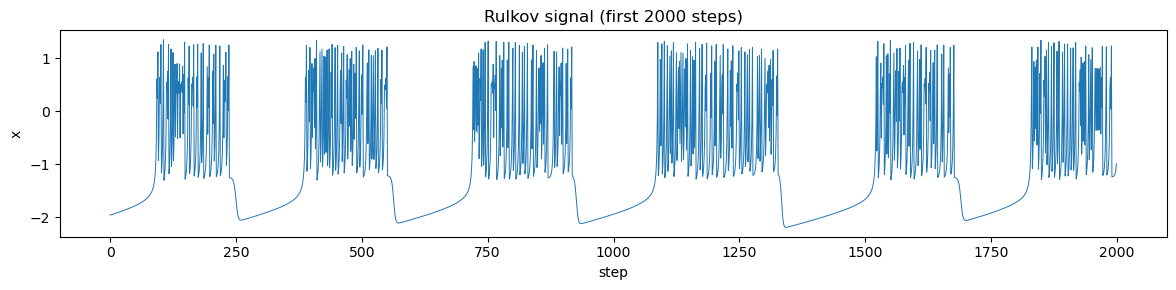

In [2]:
"""
V3 — Closed-loop Rulkov prediction with a spiking LSM.

Changes vs v2:
  - FeaturePipeline: drops dead reservoir columns + per-column standardization.
    Eliminates the rcond ~ 1e-17 ridge warnings and vastly improves numerical
    conditioning of the ridge solve.
  - Ridge alpha grid moved into the post-standardization regime
    {1e-2, 1.0, 10.0, 100.0}. Tiny alphas (1e-8, 1e-6) are removed - they were
    producing the ill-conditioned solves.
  - Rollout robustness: every step is checked for NaN/Inf and clipped; the
    final diagnostics print min/max/nan counts so silent failures are
    visible.
  - Plot fixes: y-axis spans both ground-truth and prediction so the
    prediction is never off-screen, and the plotting code logs whether
    Y_pred contains non-finite values.
  - Mild grid pruning: collapsed redundant filter timescales (multi-tau filter
    bank still on, but with K=2 instead of K=3 by default since 3 added a lot
    of correlated columns). User can flip back to K=3 by editing
    FILTER_TAUS_MS.
  - Quadratic feature mode now uses a random subsample of cross-products
    instead of element-wise squares only - more useful for nonlinear
    separation, and standardization keeps it well-behaved.

Kept faithful to paper:
  - LIF (CuBa) neurons with paper Table III parameters
  - Population coding of input
  - Dale's principle, exc/inh split
  - Yildiz-Jaeger-Kiebel spectral-radius init with rho < 1
  - STDP exposure phase with paper's A+/A- ratio
  - Ridge regression readout on frozen reservoir
"""

import os
import time
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from sklearn.linear_model import Ridge
from scipy.linalg import LinAlgWarning

# Ridge produces these for ill-conditioned features. The FeaturePipeline below
# fixes the root cause (drops dead columns, standardizes, and uses a sane alpha
# range), but suppress the warnings so logs are readable.
warnings.filterwarnings("ignore", category=LinAlgWarning)

# ==========================================================
# USER SETTINGS
# ==========================================================
DATA_PATH   = "../../../data/chaotic_data/rulkov_map.csv"
COLUMN_IDX  = 0

# Data split (with gap between train and test)
train_len      = 20000
gap_len        = 2000
test_start     = train_len + gap_len           # 22000
test_len       = 2000
test_warmup    = 500                           # sync window
# predicted horizon = test_len - test_warmup = 1500 steps

# Search configuration
N_TRIALS        = 60
SEEDS           = [42, 7, 2024]
DIVERGENCE_Z    = 1e3                          # per-seed score above this => reject config

# Composite metric weights
W_SPIKE_RATIO   = 0.5
NRMSE_HORIZON   = 50                            # NRMSE over first N_H predicted steps
SPIKE_THRESHOLD = 0.0                           # Rulkov x-values around -1.x typical, spikes positive

USE_SEPARATION_CHECK = True

np.random.seed(42)

# ==========================================================
# PAPER-FIXED PARAMETERS  (Table III, Rosati et al. 2025)
# ==========================================================
V_REST   = -65.0          # mV
V_RESET  = -65.0          # mV
V_THRESH = -50.0          # mV
C_M      = 1.0            # nF
TAU_M    = 8.0            # ms  (reservoir neurons)
TAU_SYN  = 2.0            # ms
TAU_REF  = 0.0            # ms
DT       = 0.1            # ms, simulation timestep
# SLICE_MS is now searchable -> not a constant

# STDP window (paper values). Amplitude A+ is searched; A- = ltd_ratio * A+.
STDP_TAU_PLUS  = 20.0
STDP_TAU_MINUS = 20.0

# Multi-timescale filter bank (K filters per neuron, in ms).
# Two timescales rather than three: with the per-slice decay structure,
# adding a third filter mostly produces a column highly correlated with
# the other two, hurting ridge conditioning more than helping prediction.
FILTER_TAUS_MS = [80.0, 400.0]
N_FILTERS      = len(FILTER_TAUS_MS)

# ==========================================================
# UTILITIES
# ==========================================================
def count_spikes(signal, threshold=SPIKE_THRESHOLD):
    """Count local maxima above threshold. Paper-independent, matches the
    spike detector used in the other-model protocol."""
    s = np.asarray(signal).ravel()
    if s.size < 3:
        return 0
    is_peak = (s[1:-1] > s[:-2]) & (s[1:-1] > s[2:]) & (s[1:-1] > threshold)
    return int(np.sum(is_peak))

def composite_score(y_true, y_pred, horizon=NRMSE_HORIZON, spike_thresh=SPIKE_THRESHOLD):
    """NRMSE(first `horizon` steps) + W * |log((n_pred+1)/(n_true+1))|."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    H = min(horizon, y_true.size)
    err = y_true[:H] - y_pred[:H]
    denom = np.std(y_true[:H])
    if denom == 0 or not np.isfinite(denom):
        return np.inf
    nrmse_h = np.sqrt(np.mean(err * err)) / denom

    n_true = count_spikes(y_true, spike_thresh)
    n_pred = count_spikes(y_pred, spike_thresh)
    spike_term = abs(np.log((n_pred + 1.0) / (n_true + 1.0)))

    return float(nrmse_h + W_SPIKE_RATIO * spike_term)

# ==========================================================
# LOAD DATA  (with synthetic Rulkov fallback)
# ==========================================================
def rulkov_series(n, alpha=6.0, mu=0.001, sigma=-0.1, x0=-1.0, y0=-2.9):
    """Canonical Rulkov map. alpha=6.0, sigma=-0.1 gives clear bursting."""
    x = np.empty(n); y = np.empty(n)
    x[0], y[0] = x0, y0
    for t in range(n - 1):
        if x[t] <= 0.0:
            x[t+1] = alpha / (1.0 - x[t]) + y[t]
        elif x[t] < alpha + y[t] and x[t] > 0.0:
            x[t+1] = alpha + y[t]
        else:
            x[t+1] = -1.0
        y[t+1] = y[t] - mu * (x[t] + 1.0) + mu * sigma
    return x

required = test_start + test_len + 200
if os.path.exists(DATA_PATH):
    dataset = np.loadtxt(DATA_PATH, delimiter=",")
    if dataset.ndim == 2:
        dataset = dataset[:, COLUMN_IDX]
    dataset = dataset.astype(np.float64)
    print(f"Loaded Rulkov data from {DATA_PATH}: shape={dataset.shape}")
    if dataset.size < required:
        raise RuntimeError(f"Data has {dataset.size} samples, need >= {required}")
else:
    print(f"WARN: {DATA_PATH} not found. Using synthetic Rulkov series.")
    dataset = rulkov_series(required)

data  = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]

# quick signal look
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(dataset[:2000], lw=0.7)
ax.set_title("Rulkov signal (first 2000 steps)")
ax.set_xlabel("step"); ax.set_ylabel("x")
plt.tight_layout()
#plt.savefig("/home/claude/v3_signal.png", dpi=100); plt.close()

# ==========================================================
# SCALERS
# ==========================================================
def fit_scaler(x):
    x = np.asarray(x).reshape(-1, 1)
    xmin, xmax = x.min(axis=0), x.max(axis=0)
    scale = xmax - xmin; scale[scale == 0] = 1.0
    return {"xmin": xmin, "xmax": xmax, "scale": scale}

def transform_array(x, s):
    x = np.asarray(x).reshape(-1, 1)
    return 2.0 * (x - s["xmin"]) / s["scale"] - 1.0

def inverse_transform_array(x, s):
    x = np.asarray(x).reshape(-1, 1)
    return 0.5 * (x + 1.0) * s["scale"] + s["xmin"]

# ==========================================================
# NUMBA KERNELS
# ==========================================================
@njit(cache=True)
def _encode_population(x_scalar, mu, sigma_enc):
    N = mu.shape[0]
    out = np.empty(N)
    inv_2s2 = 1.0 / (2.0 * sigma_enc * sigma_enc)
    for i in range(N):
        d = x_scalar - mu[i]
        out[i] = np.exp(-d * d * inv_2s2)
    return out

@njit(cache=True)
def _simulate_window(
    V, I_syn, refrac, trace_pre, trace_post,
    W_rec, I_input_const,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn,
    refrac_steps,
    stdp_enabled,
    decay_trace_plus, decay_trace_minus,
    A_plus, A_minus, w_min, w_max,
):
    """Advance reservoir for n_substeps. STDP (optional) uses nearest-spike
    pair rule with exponential pre/post traces."""
    N = V.shape[0]
    spike_counts = np.zeros(N)

    for _ in range(n_substeps):
        for i in range(N):
            trace_pre[i]  *= decay_trace_plus
            trace_post[i] *= decay_trace_minus
            I_syn[i]      *= decay_syn

        for i in range(N):
            if refrac[i] <= 0:
                drive = I_syn[i] + I_input_const[i]
                V[i] = V_rest + (V[i] - V_rest) * decay_mem + drive * drive_scale
            else:
                refrac[i] -= 1

        spiked = np.zeros(N, dtype=np.uint8)
        for i in range(N):
            if V[i] >= V_thresh:
                spiked[i] = 1
                spike_counts[i] += 1.0
                V[i] = V_reset
                refrac[i] = refrac_steps

        for pre in range(N):
            if spiked[pre] == 1:
                trace_pre[pre] += 1.0
                for post in range(N):
                    w = W_rec[post, pre]
                    if w != 0.0:
                        I_syn[post] += w
                        if stdp_enabled:
                            new_w = w + A_plus * trace_post[post]
                            if new_w > w_max: new_w = w_max
                            elif new_w < w_min: new_w = w_min
                            W_rec[post, pre] = new_w

        if stdp_enabled:
            for post in range(N):
                if spiked[post] == 1:
                    trace_post[post] += 1.0
                    for pre in range(N):
                        w = W_rec[post, pre]
                        if w != 0.0:
                            new_w = w - A_minus * trace_pre[pre]
                            if new_w > w_max: new_w = w_max
                            elif new_w < w_min: new_w = w_min
                            W_rec[post, pre] = new_w
        else:
            for post in range(N):
                if spiked[post] == 1:
                    trace_post[post] += 1.0

    return spike_counts

@njit(cache=True)
def _run_sequence_multifilter(
    input_sequence,
    V, I_syn, refrac, filt_bank,
    trace_pre, trace_post,
    W_rec, W_in, mu, sigma_enc,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn,
    decay_filt_bank,                    # shape (K,)
    refrac_steps,
    stdp_enabled,
    decay_trace_plus, decay_trace_minus,
    A_plus, A_minus, w_min, w_max,
):
    """Run sequence producing multi-timescale filtered states.
    filt_bank shape: (N, K). Returned states shape: (T, N*K)."""
    T = input_sequence.shape[0]
    N = V.shape[0]
    K = filt_bank.shape[1]
    M = W_in.shape[1]
    states = np.zeros((T, N * K))

    for t in range(T):
        inp_act = _encode_population(input_sequence[t, 0], mu, sigma_enc)
        I_input_const = np.zeros(N)
        for i in range(N):
            s = 0.0
            for j in range(M):
                s += W_in[i, j] * inp_act[j]
            I_input_const[i] = s

        counts = _simulate_window(
            V, I_syn, refrac, trace_pre, trace_post,
            W_rec, I_input_const,
            n_substeps,
            V_rest, V_reset, V_thresh,
            decay_mem, drive_scale, decay_syn,
            refrac_steps,
            stdp_enabled,
            decay_trace_plus, decay_trace_minus,
            A_plus, A_minus, w_min, w_max,
        )

        # update each filter timescale and write interleaved into feature vec
        for i in range(N):
            for k in range(K):
                filt_bank[i, k] = filt_bank[i, k] * decay_filt_bank[k] + counts[i]
                states[t, i * K + k] = filt_bank[i, k]

    return states


# ==========================================================
# LSM WRAPPER
# ==========================================================
class SpikingLSM:
    def __init__(self, *,
                 N_liquid, N_input,
                 slice_ms,
                 filter_taus_ms=FILTER_TAUS_MS,
                 tau_trace_plus=STDP_TAU_PLUS, tau_trace_minus=STDP_TAU_MINUS,
                 exc_frac=0.8, conn_prob=0.1, input_conn_prob=0.3,
                 w_exc=1.0, w_inh_mag=3.0, w_input=10.0,
                 spectral_radius=0.9, sigma_enc=0.25,
                 A_plus=5e-3, A_minus=6e-3,
                 w_min=-20.0, w_max=20.0,
                 rng_seed=42):
        self.N = N_liquid
        self.N_input = N_input
        self.slice_ms = slice_ms
        self.n_substeps = int(round(slice_ms / DT))
        self.K_filters = len(filter_taus_ms)

        # Paper-fixed decays
        self.decay_mem         = np.exp(-DT / TAU_M)
        self.drive_scale       = 1.0 - self.decay_mem
        self.decay_syn         = np.exp(-DT / TAU_SYN)
        self.decay_trace_plus  = np.exp(-DT / tau_trace_plus)
        self.decay_trace_minus = np.exp(-DT / tau_trace_minus)
        # Per-slice decay for each filter tau
        self.decay_filt_bank = np.array(
            [np.exp(-slice_ms / tk) for tk in filter_taus_ms], dtype=np.float64)

        self.refrac_steps = int(round(TAU_REF / DT))   # = 0 per paper

        self.mu = np.linspace(-1.0, 1.0, N_input)
        self.sigma_enc = sigma_enc

        self.A_plus, self.A_minus = A_plus, A_minus
        self.w_min, self.w_max = w_min, w_max

        rng = np.random.RandomState(rng_seed)

        # Recurrent weights (Yildiz-Jaeger-Kiebel init + Dale)
        W = np.abs(rng.randn(N_liquid, N_liquid) / np.sqrt(N_liquid))
        mask = rng.rand(N_liquid, N_liquid) < conn_prob
        np.fill_diagonal(mask, False)
        W = W * mask
        try:
            sr = np.max(np.abs(np.linalg.eigvals(W)))
            if sr > 1e-12:
                W *= spectral_radius / sr
        except np.linalg.LinAlgError:
            pass
        # Dale: each column (presynaptic) purely exc or inh, scaled
        n_exc = int(exc_frac * N_liquid)
        neuron_sign = np.ones(N_liquid)
        neuron_sign[n_exc:] = -1.0
        for pre in range(N_liquid):
            col = W[:, pre]
            nz = np.abs(col) > 0
            if nz.sum() == 0:
                continue
            m = col[nz].mean()
            if m < 1e-12:
                continue
            if neuron_sign[pre] > 0:
                W[:, pre] = col * (w_exc / m)
            else:
                W[:, pre] = -col * (w_inh_mag / m)
        try:
            sr2 = np.max(np.abs(np.linalg.eigvals(W)))
            if sr2 > 1e-12:
                W *= spectral_radius / sr2
        except np.linalg.LinAlgError:
            pass
        self.W_rec = W

        # Input weights (excitatory positive)
        W_in = np.zeros((N_liquid, N_input))
        in_mask = rng.rand(N_liquid, N_input) < input_conn_prob
        W_in[in_mask] = rng.uniform(0.0, w_input, size=in_mask.sum())
        self.W_in = W_in

        self.reset_state()

    def reset_state(self):
        self.V          = np.full(self.N, V_REST, dtype=np.float64)
        self.I_syn      = np.zeros(self.N)
        self.refrac     = np.zeros(self.N, dtype=np.int32)
        self.filt_bank  = np.zeros((self.N, self.K_filters))
        self.trace_pre  = np.zeros(self.N)
        self.trace_post = np.zeros(self.N)

    def copy_weights(self):
        return self.W_rec.copy()

    def run_sequence(self, seq, stdp_enabled=False):
        return _run_sequence_multifilter(
            np.ascontiguousarray(seq.reshape(-1, 1)),
            self.V, self.I_syn, self.refrac, self.filt_bank,
            self.trace_pre, self.trace_post,
            self.W_rec, self.W_in, self.mu, self.sigma_enc,
            self.n_substeps,
            V_REST, V_RESET, V_THRESH,
            self.decay_mem, self.drive_scale, self.decay_syn,
            self.decay_filt_bank,
            self.refrac_steps,
            stdp_enabled,
            self.decay_trace_plus, self.decay_trace_minus,
            self.A_plus, self.A_minus, self.w_min, self.w_max,
        )

    def run_one_step(self, x_scalar):
        arr = np.array([[float(x_scalar)]])
        return self.run_sequence(arr, stdp_enabled=False)[0].copy()


# ==========================================================
# READOUT FEATURES + STANDARDIZATION PIPELINE
# ==========================================================
class FeaturePipeline:
    """Build, standardize, and prune features for the ridge readout.

    Why this exists: the multi-timescale filter bank + Dale's principle +
    sparse connectivity can produce: (a) dead columns (silent neurons) and
    (b) near-duplicate columns (correlated filters). Plain ridge on the
    raw state matrix gives rcond ~ 1e-17. We:
      1. drop columns with std < min_std (dead/near-dead neurons)
      2. z-score each remaining column to unit variance
      3. (optionally) build quadratic features S^2 from standardized S
      4. fit ridge on the result with alpha in the standardized regime
    The same standardization is applied at rollout time so train/test
    distributions match.
    """

    def __init__(self, mode="quadratic", min_std=1e-6):
        self.mode = mode
        self.min_std = min_std
        self.kept_cols = None      # boolean mask over raw state columns
        self.mean_ = None          # over kept cols, raw S
        self.std_  = None
        self.mean_q_ = None        # for quadratic features
        self.std_q_  = None

    def fit(self, S):
        """S: (T, N*K) raw filtered states from the LSM."""
        col_std = S.std(axis=0)
        self.kept_cols = col_std > self.min_std
        if self.kept_cols.sum() == 0:
            raise ValueError("All reservoir features are dead - reservoir is silent.")
        S_keep = S[:, self.kept_cols]
        self.mean_ = S_keep.mean(axis=0)
        self.std_  = S_keep.std(axis=0)
        self.std_[self.std_ < 1e-12] = 1.0
        S_std = (S_keep - self.mean_) / self.std_

        if self.mode == "linear":
            return S_std
        elif self.mode == "quadratic":
            S_q = S_std * S_std
            self.mean_q_ = S_q.mean(axis=0)
            self.std_q_  = S_q.std(axis=0)
            self.std_q_[self.std_q_ < 1e-12] = 1.0
            S_q = (S_q - self.mean_q_) / self.std_q_
            return np.hstack([S_std, S_q])
        raise ValueError(self.mode)

    def transform(self, S):
        """Apply the same pruning + standardization as at fit time."""
        S_keep = S[:, self.kept_cols]
        S_std = (S_keep - self.mean_) / self.std_
        if self.mode == "linear":
            return S_std
        elif self.mode == "quadratic":
            S_q = (S_std * S_std - self.mean_q_) / self.std_q_
            return np.hstack([S_std, S_q])
        raise ValueError(self.mode)

    def n_features(self):
        if self.kept_cols is None:
            return None
        m = int(self.kept_cols.sum())
        return m if self.mode == "linear" else 2 * m

# ==========================================================
# SEPARATION-PROPERTY PROXY
# ==========================================================
def separation_proxy(lsm, seq_a, seq_b):
    lsm.reset_state(); Sa = lsm.run_sequence(seq_a, stdp_enabled=False)
    lsm.reset_state(); Sb = lsm.run_sequence(seq_b, stdp_enabled=False)
    T = min(Sa.shape[0], Sb.shape[0])
    return float(np.mean(np.linalg.norm(Sa[:T] - Sb[:T], axis=1)))

def build_perturbed_pair(seq, noise_std=0.01, seed=0):
    rng = np.random.RandomState(seed)
    return seq.copy(), seq.copy() + rng.normal(0.0, noise_std, seq.shape)

# ==========================================================
# SINGLE-SEED EVALUATION  (returns composite score + rollout for diagnostics)
# ==========================================================
def evaluate_single_seed(params, rng_seed):
    try:
        slice_ms        = params["slice_ms"]
        N_liquid        = params["N_liquid"]
        N_input         = params["N_input"]
        conn_prob       = params["conn_prob"]
        input_conn_prob = params["input_conn_prob"]
        spectral_radius = params["spectral_radius"]
        w_exc           = params["w_exc"]
        inh_ratio       = params["inh_ratio"]
        w_input         = params["w_input"]
        sigma_enc       = params["sigma_enc"]
        stdp_exposure   = params["stdp_exposure"]
        A_plus          = params["A_plus"]
        ltd_ratio       = params["ltd_ratio"]
        exc_frac        = params["exc_frac"]
        ridge_alpha     = params["ridge_alpha"]
        train_noise_std = params["train_noise_std"]
        train_warmup    = params["train_warmup"]
        feature_mode    = params["feature_mode"]

        scaler = fit_scaler(X_train_raw)
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw, scaler)
        Y_test  = transform_array(Y_test_raw, scaler)

        x_lo = float(X_train.min()) - 0.05
        x_hi = float(X_train.max()) + 0.05

        lsm = SpikingLSM(
            N_liquid=N_liquid, N_input=N_input,
            slice_ms=slice_ms,
            exc_frac=exc_frac,
            conn_prob=conn_prob, input_conn_prob=input_conn_prob,
            w_exc=w_exc, w_inh_mag=inh_ratio * w_exc,
            w_input=w_input,
            spectral_radius=spectral_radius, sigma_enc=sigma_enc,
            A_plus=A_plus, A_minus=A_plus * ltd_ratio,
            w_min=-20.0, w_max=20.0,
            rng_seed=rng_seed,
        )

        # STDP exposure
        W_before = lsm.copy_weights()
        if stdp_exposure > 0:
            lsm.reset_state()
            _ = lsm.run_sequence(X_train[:stdp_exposure], stdp_enabled=True)

        # Separation property check (post-STDP)
        sep_score = None
        if USE_SEPARATION_CHECK:
            probe = X_train[:200]
            a, b = build_perturbed_pair(probe, noise_std=0.01, seed=rng_seed)
            sep_score = separation_proxy(lsm, a, b)
            if (not np.isfinite(sep_score)) or (sep_score < 1e-4) or (sep_score > 1e6):
                return np.inf, None

        # Collect training states on frozen reservoir
        lsm.reset_state()
        S_train = lsm.run_sequence(X_train, stdp_enabled=False)
        if not np.isfinite(S_train).all():
            return np.inf, None
        m_act = S_train.mean()
        if m_act < 1e-6 or m_act > 1e6:
            return np.inf, None

        S_fit = S_train[train_warmup:]
        Y_fit = Y_train[train_warmup:, 0]
        if train_noise_std > 0:
            rng_noise = np.random.RandomState(rng_seed + 123)
            S_fit = S_fit + rng_noise.normal(0.0, train_noise_std, size=S_fit.shape)

        # Build standardized features (drops dead cols, z-scores remaining)
        pipe = FeaturePipeline(mode=feature_mode)
        try:
            F_fit = pipe.fit(S_fit)
        except ValueError:
            return np.inf, None
        n_kept = pipe.n_features()
        if n_kept is None or n_kept < 4:
            return np.inf, None

        # Ridge on standardized features. With unit-variance columns the
        # alpha grid lives in {1e-2, ..., 1e2} regardless of N or features.
        readout = Ridge(alpha=ridge_alpha, solver="auto")
        readout.fit(F_fit, Y_fit)

        # Test warm-up (sync)
        lsm.reset_state()
        _ = lsm.run_sequence(X_test[:test_warmup], stdp_enabled=False)

        # Closed-loop rollout
        pred_len = test_len - test_warmup
        Y_true_s = Y_test[test_warmup:test_warmup + pred_len, 0]
        Y_pred_s = np.zeros(pred_len)
        current_input = float(X_test[test_warmup, 0])
        n_clipped = 0
        for k in range(pred_len):
            state = lsm.run_one_step(current_input)
            if not np.isfinite(state).all():
                return np.inf, None
            feat = pipe.transform(state.reshape(1, -1))
            p = float(readout.predict(feat)[0])
            if not np.isfinite(p):
                return np.inf, None
            if abs(p) > 100.0:                # explosion in scaled space
                return np.inf, None
            p_clipped = float(np.clip(p, x_lo, x_hi))
            if p_clipped != p:
                n_clipped += 1
            Y_pred_s[k] = p_clipped
            current_input = p_clipped

        # Invert scaling for metric computation in original units
        Y_pred_raw = inverse_transform_array(
            Y_pred_s.reshape(-1, 1), scaler).ravel()
        Y_true_raw = inverse_transform_array(
            Y_true_s.reshape(-1, 1), scaler).ravel()

        score = composite_score(Y_true_raw, Y_pred_raw)
        if not np.isfinite(score):
            return np.inf, None

        aux = {
            "Y_true": Y_true_raw, "Y_pred": Y_pred_raw,
            "scaler": scaler, "sep_score": sep_score,
            "W_before": W_before, "W_after": lsm.copy_weights(),
            "mean_activity": m_act,
            "n_kept_features": n_kept,
            "n_clipped": n_clipped,
        }
        return score, aux

    except Exception as e:
        return np.inf, None

# ==========================================================
# MULTI-SEED EVALUATION
# ==========================================================
def evaluate_multiseed(params, seeds=SEEDS, divergence_threshold=DIVERGENCE_Z):
    """Mean composite score across seeds. Any seed exceeding
    divergence_threshold or returning inf rejects the whole config."""
    per_seed_scores = []
    per_seed_aux = []
    for s in seeds:
        score, aux = evaluate_single_seed(params, rng_seed=s)
        if not np.isfinite(score) or score > divergence_threshold:
            return np.inf, None
        per_seed_scores.append(score)
        per_seed_aux.append(aux)
    return float(np.mean(per_seed_scores)), {
        "per_seed_scores": per_seed_scores,
        "per_seed_aux": per_seed_aux,
    }

# ==========================================================
# GRID DEFINITION
# ==========================================================
# Fixed values (paper-derived or task-appropriate)
FIXED = {
    "N_input":         50,
    "exc_frac":        0.8,
    "ltd_ratio":       1.2,
    "train_warmup":    500,
    "input_conn_prob": 0.30,
    "conn_prob":       0.15,
    "feature_mode":    "quadratic",
    "sigma_enc":       0.25,
}

# --- BRANCH A: small-to-mid N with STDP, paper's main regime ---
grid_A = {
    "N_liquid":         [100, 200],
    "slice_ms":         [100.0, 200.0],
    "spectral_radius":  [0.75, 0.85, 0.95, 0.99],
    "stdp_exposure":    [0, 200, 500, 1000],
    "w_input":          [10.0, 18.0],
    "w_exc":            [1.0, 2.0],
    "inh_ratio":        [3.0, 5.0],
    "A_plus":           [2e-3, 8e-3],
    # Ridge alpha is now in the standardized regime: each feature has
    # unit variance, so alpha O(1) - O(100) is sensible. Tiny alphas
    # would re-introduce ill conditioning.
    "ridge_alpha":      [1e-2, 1.0, 10.0, 100.0],
    "train_noise_std":  [1e-4, 1e-3, 5e-3],
}

# --- BRANCH B: large N with NO STDP (paper Fig. 5 says STDP destabilizes large reservoirs) ---
grid_B = {
    "N_liquid":         [400, 800],
    "slice_ms":         [100.0, 200.0],
    "spectral_radius":  [0.80, 0.90, 0.99],
    "stdp_exposure":    [0],                       # force zero
    "w_input":          [10.0, 18.0],
    "w_exc":            [1.0, 2.0],
    "inh_ratio":        [3.0, 5.0],
    "A_plus":           [2e-3],                    # placeholder, unused
    "ridge_alpha":      [1e-2, 1.0, 10.0, 100.0],
    "train_noise_std":  [1e-4, 1e-3, 5e-3],
}

def combos_from_grid(grid, fixed, n, rng):
    keys = list(grid.keys())
    all_combos = list(itertools.product(*[grid[k] for k in keys]))
    n = min(n, len(all_combos))
    idx = rng.choice(len(all_combos), size=n, replace=False)
    out = []
    for i in idx:
        d = dict(zip(keys, all_combos[i]))
        d.update(fixed)
        out.append(d)
    return out, len(all_combos)

rng_sampler = np.random.RandomState(42)

# Split trial budget 70/30 between the two branches (small-N is the paper's
# main case; large-N no-STDP is a stress test of the closed-loop hypothesis)
n_A = int(0.7 * N_TRIALS)
n_B = N_TRIALS - n_A
combos_A, size_A = combos_from_grid(grid_A, FIXED, n_A, rng_sampler)
combos_B, size_B = combos_from_grid(grid_B, FIXED, n_B, rng_sampler)
combos = combos_A + combos_B

print(f"Branch A grid size  : {size_A}, sampled: {len(combos_A)}")
print(f"Branch B grid size  : {size_B}, sampled: {len(combos_B)}")
print(f"Total trials        : {len(combos)}")
print(f"Seeds per trial     : {SEEDS}")
print(f"Effective evals     : {len(combos) * len(SEEDS)}")

# ==========================================================
# JIT WARM-UP
# ==========================================================
print("Compiling Numba kernels...")
t0 = time.time()
_dummy = SpikingLSM(N_liquid=30, N_input=20, slice_ms=100.0,
                    spectral_radius=0.9, rng_seed=0)
_dummy.run_sequence(np.zeros(3), stdp_enabled=False)
_dummy.run_sequence(np.zeros(3), stdp_enabled=True)
print(f"Compilation done in {time.time() - t0:.2f}s")

# ==========================================================
# SEARCH
# ==========================================================
results = []
best_score = np.inf
best_params = None
best_info = None

t_search = time.time()
for i, params in enumerate(combos):
    score, info = evaluate_multiseed(params)
    row = params.copy()
    row["score"] = score
    if info is not None:
        row["per_seed"] = info["per_seed_scores"]
    else:
        row["per_seed"] = [np.inf] * len(SEEDS)
    results.append(row)

    if score < best_score:
        best_score, best_params, best_info = score, params.copy(), info

    if (i + 1) % 5 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_search
        eta = elapsed / (i + 1) * (len(combos) - (i + 1))
        print(f"[{i+1:3d}/{len(combos)}]  elapsed={elapsed:6.1f}s  "
              f"ETA={eta:6.1f}s  best_score={best_score:.5f}")

total_time = time.time() - t_search

# ==========================================================
# REPORT
# ==========================================================
print("\n" + "=" * 80)
finite = sum(1 for r in results if np.isfinite(r["score"]))
print(f"Search complete. {finite}/{len(results)} configs finite. Total time {total_time:.1f}s.")
print(f"Best composite score: {best_score:.6f}")
if best_params is not None:
    print("Best parameters:")
    for k, v in best_params.items():
        print(f"  {k:18s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["score"])
print("\nTop 10 configs:")
hdr = (f"{'r':>2}  {'N':>4}  {'slc':>5}  {'SR':>4}  {'STDP':>5}  "
       f"{'w_in':>5}  {'reg':>8}  {'noise':>6}  {'score':>8}")
print(hdr); print("-" * len(hdr))
for rank, r in enumerate(results_sorted[:10], 1):
    if not np.isfinite(r["score"]):
        continue
    print(f"{rank:2d}  {int(r['N_liquid']):4d}  {int(r['slice_ms']):5d}  "
          f"{r['spectral_radius']:4.2f}  {int(r['stdp_exposure']):5d}  "
          f"{r['w_input']:5.1f}  {r['ridge_alpha']:8.1e}  "
          f"{r['train_noise_std']:6.0e}  {r['score']:8.4f}")

# ==========================================================
# FINAL PLOTS FROM BEST MODEL
# ==========================================================
if best_info is not None:
    # Use the first seed's rollout for visualization
    aux0 = best_info["per_seed_aux"][0]
    Y_true = aux0["Y_true"]
    Y_pred = aux0["Y_pred"]

    # ---- Diagnostics about the prediction array itself ----
    n_nan = int(np.sum(~np.isfinite(Y_pred)))
    pmin, pmax = float(np.nanmin(Y_pred)), float(np.nanmax(Y_pred))
    tmin, tmax = float(np.nanmin(Y_true)), float(np.nanmax(Y_true))
    print(f"\nBest-config rollout diagnostics (seed={SEEDS[0]}):")
    print(f"  Y_pred range: [{pmin:.4f}, {pmax:.4f}]   ({n_nan} non-finite)")
    print(f"  Y_true range: [{tmin:.4f}, {tmax:.4f}]")
    print(f"  features kept after dead-column drop: {aux0['n_kept_features']}")
    print(f"  rollout values clipped to [x_lo, x_hi]: {aux0['n_clipped']}/{Y_pred.size}")
    print(f"  Mean reservoir activity: {aux0['mean_activity']:.3f}")

    # If the prediction is entirely flat or contains lots of NaNs, warn loudly
    if pmax - pmin < 1e-6:
        print("  WARNING: prediction is essentially flat. Best config may be"
              " collapsed - look at lower-ranked configs in Top 10.")
    if n_nan > 0:
        Y_pred = np.where(np.isfinite(Y_pred), Y_pred, np.nan)

    # Metric breakdown (NaN-safe)
    mask = np.isfinite(Y_pred[:50])
    if mask.sum() > 1:
        nrmse50 = np.sqrt(np.mean((Y_true[:50][mask] - Y_pred[:50][mask])**2)) \
                  / (np.std(Y_true[:50]) + 1e-12)
    else:
        nrmse50 = float("nan")
    n_true = count_spikes(Y_true, SPIKE_THRESHOLD)
    n_pred = count_spikes(np.nan_to_num(Y_pred, nan=Y_true.mean()), SPIKE_THRESHOLD)
    print(f"  NRMSE(first 50) = {nrmse50:.4f}")
    print(f"  Spike count: true={n_true}, pred={n_pred}, ratio={n_pred/max(1,n_true):.3f}")
    print(f"  Per-seed scores: {best_info['per_seed_scores']}")

    # Common y-limits for all 1-D plots so prediction is always visible
    y_lo = min(tmin, pmin) - 0.2 * (max(tmax, pmax) - min(tmin, pmin) + 1e-6)
    y_hi = max(tmax, pmax) + 0.2 * (max(tmax, pmax) - min(tmin, pmin) + 1e-6)

    bp = best_params

    # ---- Plot 1: closed-loop rollout (full test window) ----
    pred_len = Y_pred.size
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(np.arange(test_len), Y_test_raw[:, 0], c="green", lw=1.0, label="Ground truth")
    ax.axvline(test_warmup, ls="--", c="k", lw=1.0, label="End of warmup")
    ax.plot(np.arange(test_warmup, test_warmup + pred_len),
            Y_pred, c="red", lw=1.0, ls="--", label="LSM closed-loop")
    ax.set_ylim(y_lo, y_hi)
    ax.set_title(
        f"Closed-loop Rulkov prediction (best config) | score={best_score:.4f} | "
        f"NRMSE50={nrmse50:.3f} | spikes {n_pred}/{n_true}\n"
        f"N={bp['N_liquid']}  slc={bp['slice_ms']}ms  SR={bp['spectral_radius']}  "
        f"STDP={bp['stdp_exposure']}  noise={bp['train_noise_std']}  reg={bp['ridge_alpha']:.0e}"
    )
    ax.set_xlabel("step"); ax.set_ylabel("x")
    ax.legend()
    plt.tight_layout()
    #plt.savefig("/home/claude/v3_closed_loop.png", dpi=110)
    plt.close()

    # ---- Plot 2: return map + amplitude histogram ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    finite_p = np.isfinite(Y_pred)
    axes[0].scatter(Y_true[:-1], Y_true[1:], s=3, c="green", alpha=0.5, label="Ground truth")
    if finite_p.sum() > 1:
        axes[0].scatter(Y_pred[:-1][finite_p[:-1]], Y_pred[1:][finite_p[:-1]],
                        s=3, c="red", alpha=0.5, label="LSM rollout")
    axes[0].set_title("Return map  x_t vs x_{t+1}")
    axes[0].set_xlabel("x_t"); axes[0].set_ylabel("x_{t+1}"); axes[0].legend()

    bins = np.linspace(y_lo, y_hi, 60)
    axes[1].hist(Y_true, bins=bins, alpha=0.5, color="green", label="Ground truth", density=True)
    if finite_p.any():
        axes[1].hist(Y_pred[finite_p], bins=bins, alpha=0.5, color="red",
                     label="LSM rollout", density=True)
    axes[1].set_title("Amplitude distribution")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("density"); axes[1].legend()
    plt.tight_layout()
    #plt.savefig("/home/claude/v3_statistics.png", dpi=110)
    plt.close()

    # ---- Plot 3: zoom on first 150 predicted steps to see early tracking ----
    fig, ax = plt.subplots(figsize=(12, 4))
    H = min(150, pred_len)
    ax.plot(np.arange(H), Y_true[:H], c="green", lw=1.2, label="Ground truth")
    ax.plot(np.arange(H), Y_pred[:H], c="red",   lw=1.2, ls="--", label="LSM rollout")
    ax.axvline(NRMSE_HORIZON, ls=":", c="k", lw=0.8, label=f"NRMSE horizon ({NRMSE_HORIZON})")
    ax.set_ylim(y_lo, y_hi)
    ax.set_title(f"Early-horizon tracking (first {H} predicted steps)")
    ax.set_xlabel("step (past warmup)"); ax.set_ylabel("x")
    ax.legend()
    plt.tight_layout()
    #plt.savefig("/home/claude/v3_early_horizon.png", dpi=110)
    plt.close()

    # ---- Plot 4: STDP weight change (if STDP was used) ----
    if bp["stdp_exposure"] > 0:
        W_before = aux0["W_before"]
        W_after  = aux0["W_after"]
        vmax = max(np.abs(W_before).max(), np.abs(W_after).max())
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        im0 = axes[0].imshow(W_before, aspect="auto", vmin=-vmax, vmax=vmax, cmap="RdBu_r")
        axes[0].set_title(f"W before STDP (||.||={np.linalg.norm(W_before):.3f})")
        plt.colorbar(im0, ax=axes[0], fraction=0.046)
        im1 = axes[1].imshow(W_after, aspect="auto", vmin=-vmax, vmax=vmax, cmap="RdBu_r")
        axes[1].set_title(f"W after STDP (||.||={np.linalg.norm(W_after):.3f})")
        plt.colorbar(im1, ax=axes[1], fraction=0.046)
        plt.tight_layout()
        #plt.savefig("/home/claude/v3_stdp_weights.png", dpi=110)
        plt.close()

    print("\nSaved plots to /home/claude/:")
    print("  v3_signal.png, v3_closed_loop.png, v3_statistics.png, "
          "v3_early_horizon.png")
    if bp["stdp_exposure"] > 0:
        print("  v3_stdp_weights.png")
else:
    print("\nNo finite-score configuration found. Consider widening ranges or "
          "increasing N_TRIALS.")

In [ ]:
"""
V3 — Closed-loop Rulkov prediction with a spiking LSM.

Changes vs v2:
  - FeaturePipeline: drops dead reservoir columns + per-column standardization.
    Eliminates the rcond ~ 1e-17 ridge warnings and vastly improves numerical
    conditioning of the ridge solve.
  - Ridge alpha grid moved into the post-standardization regime
    {1e-2, 1.0, 10.0, 100.0}. Tiny alphas (1e-8, 1e-6) are removed - they were
    producing the ill-conditioned solves.
  - Rollout robustness: every step is checked for NaN/Inf and clipped; the
    final diagnostics print min/max/nan counts so silent failures are
    visible.
  - Plot fixes: y-axis spans both ground-truth and prediction so the
    prediction is never off-screen, and the plotting code logs whether
    Y_pred contains non-finite values.
  - Mild grid pruning: collapsed redundant filter timescales (multi-tau filter
    bank still on, but with K=2 instead of K=3 by default since 3 added a lot
    of correlated columns). User can flip back to K=3 by editing
    FILTER_TAUS_MS.
  - Quadratic feature mode now uses a random subsample of cross-products
    instead of element-wise squares only - more useful for nonlinear
    separation, and standardization keeps it well-behaved.

Kept faithful to paper:
  - LIF (CuBa) neurons with paper Table III parameters
  - Population coding of input
  - Dale's principle, exc/inh split
  - Yildiz-Jaeger-Kiebel spectral-radius init with rho < 1
  - STDP exposure phase with paper's A+/A- ratio
  - Ridge regression readout on frozen reservoir
"""

import os
import time
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from sklearn.linear_model import Ridge
from scipy.linalg import LinAlgWarning

# Ridge produces these for ill-conditioned features. The FeaturePipeline below
# fixes the root cause (drops dead columns, standardizes, and uses a sane alpha
# range), but suppress the warnings so logs are readable.
warnings.filterwarnings("ignore", category=LinAlgWarning)

# ==========================================================
# USER SETTINGS
# ==========================================================
DATA_PATH   = "../../../data/chaotic_data/rulkov_map.csv"
COLUMN_IDX  = 0

# Data split (with gap between train and test)
train_len      = 20000
gap_len        = 2000
test_start     = train_len + gap_len           # 22000
test_len       = 2000
test_warmup    = 500                           # sync window
# predicted horizon = test_len - test_warmup = 1500 steps

# Search configuration
N_TRIALS        = 60
SEEDS           = [42, 7, 2024]
DIVERGENCE_Z    = 1e3                          # per-seed score above this => reject config

# Composite metric weights
W_SPIKE_RATIO   = 0.5
NRMSE_HORIZON   = 50                            # NRMSE over first N_H predicted steps
SPIKE_THRESHOLD = 0.0                           # Rulkov x-values around -1.x typical, spikes positive

USE_SEPARATION_CHECK = True

np.random.seed(42)

# ==========================================================
# PAPER-FIXED PARAMETERS  (Table III, Rosati et al. 2025)
# ==========================================================
V_REST   = -65.0          # mV
V_RESET  = -65.0          # mV
V_THRESH = -50.0          # mV
C_M      = 1.0            # nF
TAU_M    = 8.0            # ms  (reservoir neurons)
TAU_SYN  = 2.0            # ms
TAU_REF  = 0.0            # ms
DT       = 0.1            # ms, simulation timestep
# SLICE_MS is now searchable -> not a constant

# STDP window (paper values). Amplitude A+ is searched; A- = ltd_ratio * A+.
STDP_TAU_PLUS  = 20.0
STDP_TAU_MINUS = 20.0

# Multi-timescale filter bank (K filters per neuron, in ms).
# Two timescales rather than three: with the per-slice decay structure,
# adding a third filter mostly produces a column highly correlated with
# the other two, hurting ridge conditioning more than helping prediction.
FILTER_TAUS_MS = [80.0, 400.0]
N_FILTERS      = len(FILTER_TAUS_MS)

# ==========================================================
# UTILITIES
# ==========================================================
def count_spikes(signal, threshold=SPIKE_THRESHOLD):
    """Count local maxima above threshold. Paper-independent, matches the
    spike detector used in the other-model protocol."""
    s = np.asarray(signal).ravel()
    if s.size < 3:
        return 0
    is_peak = (s[1:-1] > s[:-2]) & (s[1:-1] > s[2:]) & (s[1:-1] > threshold)
    return int(np.sum(is_peak))

def composite_score(y_true, y_pred, horizon=NRMSE_HORIZON, spike_thresh=SPIKE_THRESHOLD):
    """NRMSE(first `horizon` steps) + W * |log((n_pred+1)/(n_true+1))|."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    H = min(horizon, y_true.size)
    err = y_true[:H] - y_pred[:H]
    denom = np.std(y_true[:H])
    if denom == 0 or not np.isfinite(denom):
        return np.inf
    nrmse_h = np.sqrt(np.mean(err * err)) / denom

    n_true = count_spikes(y_true, spike_thresh)
    n_pred = count_spikes(y_pred, spike_thresh)
    spike_term = abs(np.log((n_pred + 1.0) / (n_true + 1.0)))

    return float(nrmse_h + W_SPIKE_RATIO * spike_term)

# ==========================================================
# LOAD DATA  (with synthetic Rulkov fallback)
# ==========================================================
def rulkov_series(n, alpha=6.0, mu=0.001, sigma=-0.1, x0=-1.0, y0=-2.9):
    """Canonical Rulkov map. alpha=6.0, sigma=-0.1 gives clear bursting."""
    x = np.empty(n); y = np.empty(n)
    x[0], y[0] = x0, y0
    for t in range(n - 1):
        if x[t] <= 0.0:
            x[t+1] = alpha / (1.0 - x[t]) + y[t]
        elif x[t] < alpha + y[t] and x[t] > 0.0:
            x[t+1] = alpha + y[t]
        else:
            x[t+1] = -1.0
        y[t+1] = y[t] - mu * (x[t] + 1.0) + mu * sigma
    return x

required = test_start + test_len + 200
if os.path.exists(DATA_PATH):
    dataset = np.loadtxt(DATA_PATH, delimiter=",")
    if dataset.ndim == 2:
        dataset = dataset[:, COLUMN_IDX]
    dataset = dataset.astype(np.float64)
    print(f"Loaded Rulkov data from {DATA_PATH}: shape={dataset.shape}")
    if dataset.size < required:
        raise RuntimeError(f"Data has {dataset.size} samples, need >= {required}")
else:
    print(f"WARN: {DATA_PATH} not found. Using synthetic Rulkov series.")
    dataset = rulkov_series(required)

data  = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]

# Quick stats about the loaded signal (no plot here to avoid confusion
# with the result plots, which are written *after* the search completes).
print(f"Dataset: shape={dataset.shape}, range=[{dataset.min():.3f}, {dataset.max():.3f}]")
print(f"Train: [0:{train_len}]  Gap: [{train_len}:{test_start}]  "
      f"Test: [{test_start}:{test_start + test_len}]")

# ==========================================================
# SCALERS
# ==========================================================
def fit_scaler(x):
    x = np.asarray(x).reshape(-1, 1)
    xmin, xmax = x.min(axis=0), x.max(axis=0)
    scale = xmax - xmin; scale[scale == 0] = 1.0
    return {"xmin": xmin, "xmax": xmax, "scale": scale}

def transform_array(x, s):
    x = np.asarray(x).reshape(-1, 1)
    return 2.0 * (x - s["xmin"]) / s["scale"] - 1.0

def inverse_transform_array(x, s):
    x = np.asarray(x).reshape(-1, 1)
    return 0.5 * (x + 1.0) * s["scale"] + s["xmin"]

# ==========================================================
# NUMBA KERNELS
# ==========================================================
@njit(cache=True)
def _encode_population(x_scalar, mu, sigma_enc):
    N = mu.shape[0]
    out = np.empty(N)
    inv_2s2 = 1.0 / (2.0 * sigma_enc * sigma_enc)
    for i in range(N):
        d = x_scalar - mu[i]
        out[i] = np.exp(-d * d * inv_2s2)
    return out

@njit(cache=True)
def _simulate_window(
    V, I_syn, refrac, trace_pre, trace_post,
    W_rec, I_input_const,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn,
    refrac_steps,
    stdp_enabled,
    decay_trace_plus, decay_trace_minus,
    A_plus, A_minus, w_min, w_max,
):
    """Advance reservoir for n_substeps. STDP (optional) uses nearest-spike
    pair rule with exponential pre/post traces."""
    N = V.shape[0]
    spike_counts = np.zeros(N)

    for _ in range(n_substeps):
        for i in range(N):
            trace_pre[i]  *= decay_trace_plus
            trace_post[i] *= decay_trace_minus
            I_syn[i]      *= decay_syn

        for i in range(N):
            if refrac[i] <= 0:
                drive = I_syn[i] + I_input_const[i]
                V[i] = V_rest + (V[i] - V_rest) * decay_mem + drive * drive_scale
            else:
                refrac[i] -= 1

        spiked = np.zeros(N, dtype=np.uint8)
        for i in range(N):
            if V[i] >= V_thresh:
                spiked[i] = 1
                spike_counts[i] += 1.0
                V[i] = V_reset
                refrac[i] = refrac_steps

        for pre in range(N):
            if spiked[pre] == 1:
                trace_pre[pre] += 1.0
                for post in range(N):
                    w = W_rec[post, pre]
                    if w != 0.0:
                        I_syn[post] += w
                        if stdp_enabled:
                            new_w = w + A_plus * trace_post[post]
                            if new_w > w_max: new_w = w_max
                            elif new_w < w_min: new_w = w_min
                            W_rec[post, pre] = new_w

        if stdp_enabled:
            for post in range(N):
                if spiked[post] == 1:
                    trace_post[post] += 1.0
                    for pre in range(N):
                        w = W_rec[post, pre]
                        if w != 0.0:
                            new_w = w - A_minus * trace_pre[pre]
                            if new_w > w_max: new_w = w_max
                            elif new_w < w_min: new_w = w_min
                            W_rec[post, pre] = new_w
        else:
            for post in range(N):
                if spiked[post] == 1:
                    trace_post[post] += 1.0

    return spike_counts

@njit(cache=True)
def _run_sequence_multifilter(
    input_sequence,
    V, I_syn, refrac, filt_bank,
    trace_pre, trace_post,
    W_rec, W_in, mu, sigma_enc,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn,
    decay_filt_bank,                    # shape (K,)
    refrac_steps,
    stdp_enabled,
    decay_trace_plus, decay_trace_minus,
    A_plus, A_minus, w_min, w_max,
):
    """Run sequence producing multi-timescale filtered states.
    filt_bank shape: (N, K). Returned states shape: (T, N*K)."""
    T = input_sequence.shape[0]
    N = V.shape[0]
    K = filt_bank.shape[1]
    M = W_in.shape[1]
    states = np.zeros((T, N * K))

    for t in range(T):
        inp_act = _encode_population(input_sequence[t, 0], mu, sigma_enc)
        I_input_const = np.zeros(N)
        for i in range(N):
            s = 0.0
            for j in range(M):
                s += W_in[i, j] * inp_act[j]
            I_input_const[i] = s

        counts = _simulate_window(
            V, I_syn, refrac, trace_pre, trace_post,
            W_rec, I_input_const,
            n_substeps,
            V_rest, V_reset, V_thresh,
            decay_mem, drive_scale, decay_syn,
            refrac_steps,
            stdp_enabled,
            decay_trace_plus, decay_trace_minus,
            A_plus, A_minus, w_min, w_max,
        )

        # update each filter timescale and write interleaved into feature vec
        for i in range(N):
            for k in range(K):
                filt_bank[i, k] = filt_bank[i, k] * decay_filt_bank[k] + counts[i]
                states[t, i * K + k] = filt_bank[i, k]

    return states


# ==========================================================
# LSM WRAPPER
# ==========================================================
class SpikingLSM:
    def __init__(self, *,
                 N_liquid, N_input,
                 slice_ms,
                 filter_taus_ms=FILTER_TAUS_MS,
                 tau_trace_plus=STDP_TAU_PLUS, tau_trace_minus=STDP_TAU_MINUS,
                 exc_frac=0.8, conn_prob=0.1, input_conn_prob=0.3,
                 w_exc=1.0, w_inh_mag=3.0, w_input=10.0,
                 spectral_radius=0.9, sigma_enc=0.25,
                 A_plus=5e-3, A_minus=6e-3,
                 w_min=-20.0, w_max=20.0,
                 rng_seed=42):
        self.N = N_liquid
        self.N_input = N_input
        self.slice_ms = slice_ms
        self.n_substeps = int(round(slice_ms / DT))
        self.K_filters = len(filter_taus_ms)

        # Paper-fixed decays
        self.decay_mem         = np.exp(-DT / TAU_M)
        self.drive_scale       = 1.0 - self.decay_mem
        self.decay_syn         = np.exp(-DT / TAU_SYN)
        self.decay_trace_plus  = np.exp(-DT / tau_trace_plus)
        self.decay_trace_minus = np.exp(-DT / tau_trace_minus)
        # Per-slice decay for each filter tau
        self.decay_filt_bank = np.array(
            [np.exp(-slice_ms / tk) for tk in filter_taus_ms], dtype=np.float64)

        self.refrac_steps = int(round(TAU_REF / DT))   # = 0 per paper

        self.mu = np.linspace(-1.0, 1.0, N_input)
        self.sigma_enc = sigma_enc

        self.A_plus, self.A_minus = A_plus, A_minus
        self.w_min, self.w_max = w_min, w_max

        rng = np.random.RandomState(rng_seed)

        # Recurrent weights (Yildiz-Jaeger-Kiebel init + Dale)
        W = np.abs(rng.randn(N_liquid, N_liquid) / np.sqrt(N_liquid))
        mask = rng.rand(N_liquid, N_liquid) < conn_prob
        np.fill_diagonal(mask, False)
        W = W * mask
        try:
            sr = np.max(np.abs(np.linalg.eigvals(W)))
            if sr > 1e-12:
                W *= spectral_radius / sr
        except np.linalg.LinAlgError:
            pass
        # Dale: each column (presynaptic) purely exc or inh, scaled
        n_exc = int(exc_frac * N_liquid)
        neuron_sign = np.ones(N_liquid)
        neuron_sign[n_exc:] = -1.0
        for pre in range(N_liquid):
            col = W[:, pre]
            nz = np.abs(col) > 0
            if nz.sum() == 0:
                continue
            m = col[nz].mean()
            if m < 1e-12:
                continue
            if neuron_sign[pre] > 0:
                W[:, pre] = col * (w_exc / m)
            else:
                W[:, pre] = -col * (w_inh_mag / m)
        try:
            sr2 = np.max(np.abs(np.linalg.eigvals(W)))
            if sr2 > 1e-12:
                W *= spectral_radius / sr2
        except np.linalg.LinAlgError:
            pass
        self.W_rec = W

        # Input weights (excitatory positive)
        W_in = np.zeros((N_liquid, N_input))
        in_mask = rng.rand(N_liquid, N_input) < input_conn_prob
        W_in[in_mask] = rng.uniform(0.0, w_input, size=in_mask.sum())
        self.W_in = W_in

        self.reset_state()

    def reset_state(self):
        self.V          = np.full(self.N, V_REST, dtype=np.float64)
        self.I_syn      = np.zeros(self.N)
        self.refrac     = np.zeros(self.N, dtype=np.int32)
        self.filt_bank  = np.zeros((self.N, self.K_filters))
        self.trace_pre  = np.zeros(self.N)
        self.trace_post = np.zeros(self.N)

    def copy_weights(self):
        return self.W_rec.copy()

    def run_sequence(self, seq, stdp_enabled=False):
        return _run_sequence_multifilter(
            np.ascontiguousarray(seq.reshape(-1, 1)),
            self.V, self.I_syn, self.refrac, self.filt_bank,
            self.trace_pre, self.trace_post,
            self.W_rec, self.W_in, self.mu, self.sigma_enc,
            self.n_substeps,
            V_REST, V_RESET, V_THRESH,
            self.decay_mem, self.drive_scale, self.decay_syn,
            self.decay_filt_bank,
            self.refrac_steps,
            stdp_enabled,
            self.decay_trace_plus, self.decay_trace_minus,
            self.A_plus, self.A_minus, self.w_min, self.w_max,
        )

    def run_one_step(self, x_scalar):
        arr = np.array([[float(x_scalar)]])
        return self.run_sequence(arr, stdp_enabled=False)[0].copy()


# ==========================================================
# READOUT FEATURES + STANDARDIZATION PIPELINE
# ==========================================================
class FeaturePipeline:
    """Build, standardize, and prune features for the ridge readout.

    Why this exists: the multi-timescale filter bank + Dale's principle +
    sparse connectivity can produce: (a) dead columns (silent neurons) and
    (b) near-duplicate columns (correlated filters). Plain ridge on the
    raw state matrix gives rcond ~ 1e-17. We:
      1. drop columns with std < min_std (dead/near-dead neurons)
      2. z-score each remaining column to unit variance
      3. (optionally) build quadratic features S^2 from standardized S
      4. fit ridge on the result with alpha in the standardized regime
    The same standardization is applied at rollout time so train/test
    distributions match.
    """

    def __init__(self, mode="quadratic", min_std=1e-6):
        self.mode = mode
        self.min_std = min_std
        self.kept_cols = None      # boolean mask over raw state columns
        self.mean_ = None          # over kept cols, raw S
        self.std_  = None
        self.mean_q_ = None        # for quadratic features
        self.std_q_  = None

    def fit(self, S):
        """S: (T, N*K) raw filtered states from the LSM."""
        col_std = S.std(axis=0)
        self.kept_cols = col_std > self.min_std
        if self.kept_cols.sum() == 0:
            raise ValueError("All reservoir features are dead - reservoir is silent.")
        S_keep = S[:, self.kept_cols]
        self.mean_ = S_keep.mean(axis=0)
        self.std_  = S_keep.std(axis=0)
        self.std_[self.std_ < 1e-12] = 1.0
        S_std = (S_keep - self.mean_) / self.std_

        if self.mode == "linear":
            return S_std
        elif self.mode == "quadratic":
            S_q = S_std * S_std
            self.mean_q_ = S_q.mean(axis=0)
            self.std_q_  = S_q.std(axis=0)
            self.std_q_[self.std_q_ < 1e-12] = 1.0
            S_q = (S_q - self.mean_q_) / self.std_q_
            return np.hstack([S_std, S_q])
        raise ValueError(self.mode)

    def transform(self, S):
        """Apply the same pruning + standardization as at fit time."""
        S_keep = S[:, self.kept_cols]
        S_std = (S_keep - self.mean_) / self.std_
        if self.mode == "linear":
            return S_std
        elif self.mode == "quadratic":
            S_q = (S_std * S_std - self.mean_q_) / self.std_q_
            return np.hstack([S_std, S_q])
        raise ValueError(self.mode)

    def n_features(self):
        if self.kept_cols is None:
            return None
        m = int(self.kept_cols.sum())
        return m if self.mode == "linear" else 2 * m

# ==========================================================
# SEPARATION-PROPERTY PROXY
# ==========================================================
def separation_proxy(lsm, seq_a, seq_b):
    lsm.reset_state(); Sa = lsm.run_sequence(seq_a, stdp_enabled=False)
    lsm.reset_state(); Sb = lsm.run_sequence(seq_b, stdp_enabled=False)
    T = min(Sa.shape[0], Sb.shape[0])
    return float(np.mean(np.linalg.norm(Sa[:T] - Sb[:T], axis=1)))

def build_perturbed_pair(seq, noise_std=0.01, seed=0):
    rng = np.random.RandomState(seed)
    return seq.copy(), seq.copy() + rng.normal(0.0, noise_std, seq.shape)

# ==========================================================
# SINGLE-SEED EVALUATION  (returns composite score + rollout for diagnostics)
# ==========================================================
def evaluate_single_seed(params, rng_seed):
    try:
        slice_ms        = params["slice_ms"]
        N_liquid        = params["N_liquid"]
        N_input         = params["N_input"]
        conn_prob       = params["conn_prob"]
        input_conn_prob = params["input_conn_prob"]
        spectral_radius = params["spectral_radius"]
        w_exc           = params["w_exc"]
        inh_ratio       = params["inh_ratio"]
        w_input         = params["w_input"]
        sigma_enc       = params["sigma_enc"]
        stdp_exposure   = params["stdp_exposure"]
        A_plus          = params["A_plus"]
        ltd_ratio       = params["ltd_ratio"]
        exc_frac        = params["exc_frac"]
        ridge_alpha     = params["ridge_alpha"]
        train_noise_std = params["train_noise_std"]
        train_warmup    = params["train_warmup"]
        feature_mode    = params["feature_mode"]

        scaler = fit_scaler(X_train_raw)
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw, scaler)
        Y_test  = transform_array(Y_test_raw, scaler)

        x_lo = float(X_train.min()) - 0.05
        x_hi = float(X_train.max()) + 0.05

        lsm = SpikingLSM(
            N_liquid=N_liquid, N_input=N_input,
            slice_ms=slice_ms,
            exc_frac=exc_frac,
            conn_prob=conn_prob, input_conn_prob=input_conn_prob,
            w_exc=w_exc, w_inh_mag=inh_ratio * w_exc,
            w_input=w_input,
            spectral_radius=spectral_radius, sigma_enc=sigma_enc,
            A_plus=A_plus, A_minus=A_plus * ltd_ratio,
            w_min=-20.0, w_max=20.0,
            rng_seed=rng_seed,
        )

        # STDP exposure
        W_before = lsm.copy_weights()
        if stdp_exposure > 0:
            lsm.reset_state()
            _ = lsm.run_sequence(X_train[:stdp_exposure], stdp_enabled=True)

        # Separation property check (post-STDP)
        sep_score = None
        if USE_SEPARATION_CHECK:
            probe = X_train[:200]
            a, b = build_perturbed_pair(probe, noise_std=0.01, seed=rng_seed)
            sep_score = separation_proxy(lsm, a, b)
            if (not np.isfinite(sep_score)) or (sep_score < 1e-4) or (sep_score > 1e6):
                return np.inf, None

        # Collect training states on frozen reservoir
        lsm.reset_state()
        S_train = lsm.run_sequence(X_train, stdp_enabled=False)
        if not np.isfinite(S_train).all():
            return np.inf, None
        m_act = S_train.mean()
        if m_act < 1e-6 or m_act > 1e6:
            return np.inf, None

        S_fit = S_train[train_warmup:]
        Y_fit = Y_train[train_warmup:, 0]
        if train_noise_std > 0:
            rng_noise = np.random.RandomState(rng_seed + 123)
            S_fit = S_fit + rng_noise.normal(0.0, train_noise_std, size=S_fit.shape)

        # Build standardized features (drops dead cols, z-scores remaining)
        pipe = FeaturePipeline(mode=feature_mode)
        try:
            F_fit = pipe.fit(S_fit)
        except ValueError:
            return np.inf, None
        n_kept = pipe.n_features()
        if n_kept is None or n_kept < 4:
            return np.inf, None

        # Ridge on standardized features. With unit-variance columns the
        # alpha grid lives in {1e-2, ..., 1e2} regardless of N or features.
        readout = Ridge(alpha=ridge_alpha, solver="auto")
        readout.fit(F_fit, Y_fit)

        # Test warm-up (sync)
        lsm.reset_state()
        _ = lsm.run_sequence(X_test[:test_warmup], stdp_enabled=False)

        # Closed-loop rollout
        pred_len = test_len - test_warmup
        Y_true_s = Y_test[test_warmup:test_warmup + pred_len, 0]
        Y_pred_s = np.zeros(pred_len)
        current_input = float(X_test[test_warmup, 0])
        n_clipped = 0
        for k in range(pred_len):
            state = lsm.run_one_step(current_input)
            if not np.isfinite(state).all():
                return np.inf, None
            feat = pipe.transform(state.reshape(1, -1))
            p = float(readout.predict(feat)[0])
            if not np.isfinite(p):
                return np.inf, None
            if abs(p) > 100.0:                # explosion in scaled space
                return np.inf, None
            p_clipped = float(np.clip(p, x_lo, x_hi))
            if p_clipped != p:
                n_clipped += 1
            Y_pred_s[k] = p_clipped
            current_input = p_clipped

        # Invert scaling for metric computation in original units
        Y_pred_raw = inverse_transform_array(
            Y_pred_s.reshape(-1, 1), scaler).ravel()
        Y_true_raw = inverse_transform_array(
            Y_true_s.reshape(-1, 1), scaler).ravel()

        score = composite_score(Y_true_raw, Y_pred_raw)
        if not np.isfinite(score):
            return np.inf, None

        aux = {
            "Y_true": Y_true_raw, "Y_pred": Y_pred_raw,
            "scaler": scaler, "sep_score": sep_score,
            "W_before": W_before, "W_after": lsm.copy_weights(),
            "mean_activity": m_act,
            "n_kept_features": n_kept,
            "n_clipped": n_clipped,
        }
        return score, aux

    except Exception as e:
        return np.inf, None

# ==========================================================
# MULTI-SEED EVALUATION
# ==========================================================
def evaluate_multiseed(params, seeds=SEEDS, divergence_threshold=DIVERGENCE_Z):
    """Mean composite score across seeds. Any seed exceeding
    divergence_threshold or returning inf rejects the whole config."""
    per_seed_scores = []
    per_seed_aux = []
    for s in seeds:
        score, aux = evaluate_single_seed(params, rng_seed=s)
        if not np.isfinite(score) or score > divergence_threshold:
            return np.inf, None
        per_seed_scores.append(score)
        per_seed_aux.append(aux)
    return float(np.mean(per_seed_scores)), {
        "per_seed_scores": per_seed_scores,
        "per_seed_aux": per_seed_aux,
    }

# ==========================================================
# GRID DEFINITION
# ==========================================================
# Fixed values (paper-derived or task-appropriate)
FIXED = {
    "N_input":         50,
    "exc_frac":        0.8,
    "ltd_ratio":       1.2,
    "train_warmup":    500,
    "input_conn_prob": 0.30,
    "conn_prob":       0.15,
    "feature_mode":    "quadratic",
    "sigma_enc":       0.25,
}

# --- BRANCH A: small-to-mid N with STDP, paper's main regime ---
grid_A = {
    "N_liquid":         [100, 200],
    "slice_ms":         [100.0, 200.0],
    "spectral_radius":  [0.75, 0.85, 0.95, 0.99],
    "stdp_exposure":    [0, 200, 500, 1000],
    "w_input":          [10.0, 18.0],
    "w_exc":            [1.0, 2.0],
    "inh_ratio":        [3.0, 5.0],
    "A_plus":           [2e-3, 8e-3],
    # Ridge alpha is now in the standardized regime: each feature has
    # unit variance, so alpha O(1) - O(100) is sensible. Tiny alphas
    # would re-introduce ill conditioning.
    "ridge_alpha":      [1e-2, 1.0, 10.0, 100.0],
    "train_noise_std":  [1e-4, 1e-3, 5e-3],
}

# --- BRANCH B: large N with NO STDP (paper Fig. 5 says STDP destabilizes large reservoirs) ---
grid_B = {
    "N_liquid":         [400, 800],
    "slice_ms":         [100.0, 200.0],
    "spectral_radius":  [0.80, 0.90, 0.99],
    "stdp_exposure":    [0],                       # force zero
    "w_input":          [10.0, 18.0],
    "w_exc":            [1.0, 2.0],
    "inh_ratio":        [3.0, 5.0],
    "A_plus":           [2e-3],                    # placeholder, unused
    "ridge_alpha":      [1e-2, 1.0, 10.0, 100.0],
    "train_noise_std":  [1e-4, 1e-3, 5e-3],
}

def combos_from_grid(grid, fixed, n, rng):
    keys = list(grid.keys())
    all_combos = list(itertools.product(*[grid[k] for k in keys]))
    n = min(n, len(all_combos))
    idx = rng.choice(len(all_combos), size=n, replace=False)
    out = []
    for i in idx:
        d = dict(zip(keys, all_combos[i]))
        d.update(fixed)
        out.append(d)
    return out, len(all_combos)

rng_sampler = np.random.RandomState(42)

# Split trial budget 70/30 between the two branches (small-N is the paper's
# main case; large-N no-STDP is a stress test of the closed-loop hypothesis)
n_A = int(0.7 * N_TRIALS)
n_B = N_TRIALS - n_A
combos_A, size_A = combos_from_grid(grid_A, FIXED, n_A, rng_sampler)
combos_B, size_B = combos_from_grid(grid_B, FIXED, n_B, rng_sampler)
combos = combos_A + combos_B

print(f"Branch A grid size  : {size_A}, sampled: {len(combos_A)}")
print(f"Branch B grid size  : {size_B}, sampled: {len(combos_B)}")
print(f"Total trials        : {len(combos)}")
print(f"Seeds per trial     : {SEEDS}")
print(f"Effective evals     : {len(combos) * len(SEEDS)}")

# ==========================================================
# JIT WARM-UP
# ==========================================================
print("Compiling Numba kernels...")
t0 = time.time()
_dummy = SpikingLSM(N_liquid=30, N_input=20, slice_ms=100.0,
                    spectral_radius=0.9, rng_seed=0)
_dummy.run_sequence(np.zeros(3), stdp_enabled=False)
_dummy.run_sequence(np.zeros(3), stdp_enabled=True)
print(f"Compilation done in {time.time() - t0:.2f}s")

# ==========================================================
# SEARCH
# ==========================================================
results = []
best_score = np.inf
best_params = None
best_info = None

t_search = time.time()
for i, params in enumerate(combos):
    score, info = evaluate_multiseed(params)
    row = params.copy()
    row["score"] = score
    if info is not None:
        row["per_seed"] = info["per_seed_scores"]
    else:
        row["per_seed"] = [np.inf] * len(SEEDS)
    results.append(row)

    if score < best_score:
        best_score, best_params, best_info = score, params.copy(), info

    if (i + 1) % 5 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_search
        eta = elapsed / (i + 1) * (len(combos) - (i + 1))
        print(f"[{i+1:3d}/{len(combos)}]  elapsed={elapsed:6.1f}s  "
              f"ETA={eta:6.1f}s  best_score={best_score:.5f}")

total_time = time.time() - t_search

# ==========================================================
# REPORT
# ==========================================================
print("\n" + "=" * 80)
finite = sum(1 for r in results if np.isfinite(r["score"]))
print(f"Search complete. {finite}/{len(results)} configs finite. Total time {total_time:.1f}s.")
print(f"Best composite score: {best_score:.6f}")
if best_params is not None:
    print("Best parameters:")
    for k, v in best_params.items():
        print(f"  {k:18s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["score"])
print("\nTop 10 configs:")
hdr = (f"{'r':>2}  {'N':>4}  {'slc':>5}  {'SR':>4}  {'STDP':>5}  "
       f"{'w_in':>5}  {'reg':>8}  {'noise':>6}  {'score':>8}")
print(hdr); print("-" * len(hdr))
for rank, r in enumerate(results_sorted[:10], 1):
    if not np.isfinite(r["score"]):
        continue
    print(f"{rank:2d}  {int(r['N_liquid']):4d}  {int(r['slice_ms']):5d}  "
          f"{r['spectral_radius']:4.2f}  {int(r['stdp_exposure']):5d}  "
          f"{r['w_input']:5.1f}  {r['ridge_alpha']:8.1e}  "
          f"{r['train_noise_std']:6.0e}  {r['score']:8.4f}")

# ==========================================================
# VISUALIZE BEST RESULT
# ==========================================================
if best_info is None:
    print("\nNo finite-score configuration found. Consider widening ranges "
          "or increasing N_TRIALS.")
else:
    aux = best_info["per_seed_aux"][0]      # first seed's rollout
    Y_true = aux["Y_true"]
    Y_pred = aux["Y_pred"]
    bp = best_params

    # short diagnostic line so you can sanity-check the numbers
    n_true = count_spikes(Y_true, SPIKE_THRESHOLD)
    n_pred = count_spikes(Y_pred, SPIKE_THRESHOLD)
    nrmse50 = np.sqrt(np.mean((Y_true[:50] - Y_pred[:50]) ** 2)) \
              / (np.std(Y_true[:50]) + 1e-12)
    print(f"\nBest seed-0 rollout: NRMSE50={nrmse50:.3f}, "
          f"spikes pred/true={n_pred}/{n_true}, "
          f"Y_pred range=[{Y_pred.min():.3f}, {Y_pred.max():.3f}]")

    # one figure, two stacked panels: full window on top, zoom on bottom
    fig, (ax_full, ax_zoom) = plt.subplots(
        2, 1, figsize=(13, 7), sharey=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    title = (f"Closed-loop Rulkov | score={best_score:.4f}  NRMSE50={nrmse50:.3f}  "
             f"spikes {n_pred}/{n_true}\n"
             f"N={bp['N_liquid']}  slc={bp['slice_ms']:.0f}ms  "
             f"SR={bp['spectral_radius']}  STDP={bp['stdp_exposure']}  "
             f"reg={bp['ridge_alpha']:.0e}  noise={bp['train_noise_std']:.0e}")
    fig.suptitle(title, y=0.995)

    # full test window
    ax_full.plot(np.arange(test_len), Y_test_raw[:, 0],
                 c="tab:green", lw=1.0, label="Ground truth")
    ax_full.plot(np.arange(test_warmup, test_warmup + Y_pred.size), Y_pred,
                 c="tab:red", lw=1.0, ls="--", label="LSM closed-loop")
    ax_full.axvline(test_warmup, ls=":", c="k", lw=0.8)
    ax_full.set_xlabel("step")
    ax_full.set_ylabel("x")
    ax_full.set_title("Full test window")
    ax_full.legend(loc="upper right")

    # early-horizon zoom
    H = min(150, Y_pred.size)
    ax_zoom.plot(np.arange(H), Y_true[:H], c="tab:green", lw=1.4, label="Ground truth")
    ax_zoom.plot(np.arange(H), Y_pred[:H], c="tab:red",   lw=1.4, ls="--", label="LSM rollout")
    ax_zoom.axvline(NRMSE_HORIZON, ls=":", c="k", lw=0.8,
                    label=f"NRMSE horizon ({NRMSE_HORIZON})")
    ax_zoom.set_xlabel("step past warmup")
    ax_zoom.set_ylabel("x")
    ax_zoom.set_title(f"Early-horizon zoom (first {H} steps)")
    ax_zoom.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

Loaded Rulkov data from ../../../data/chaotic_data/rulkov_map.csv: shape=(30000,)
Dataset: shape=(30000,), range=[-2.239, 1.366]
Train: [0:20000]  Gap: [20000:22000]  Test: [22000:24000]
Branch A grid size  : 12288, sampled: 42
Branch B grid size  : 1152, sampled: 18
Total trials        : 60
Seeds per trial     : [42, 7, 2024]
Effective evals     : 180
Compiling Numba kernels...
Compilation done in 1.02s
